## Importing of Libraries :
 - Pandas
 - Numpy
 - PrettyPrint

In [1]:
import pandas as pd
import numpy as np
from pprint import pprint

##  Data Exploration : ##

In [ ]:
df = pd.read_csv('data.csv')
df.head(5)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [7]:
pprint(df.isnull().sum())
print(f"The number of duplicate rows is: {df.duplicated().sum()}")

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [5]:
print(f"The columns in the DataFrame are: {df.columns.tolist()}\nThe number of rows and columns in the DataFrame are: {df.shape}")

The columns in the DataFrame are: ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
The number of rows and columns in the DataFrame are: (1470, 35)


In [6]:
print(f"Different entries for 'BusinessTravel': {df['BusinessTravel'].unique()}\n")
print(f"Different entries for 'Department': {df['Department'].unique()}\n")
print(f"Different entries for 'EducationField': {df['EducationField'].unique()}\n")
print(f"Different entries for job role: {df['JobRole'].unique()}\n")
print(f"Different entries for 'MaritalStatus': {df['MaritalStatus'].unique()}\n")

Different entries for 'BusinessTravel': ['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']

Different entries for 'Department': ['Sales' 'Research & Development' 'Human Resources']

Different entries for 'EducationField': ['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree'
 'Human Resources']

Different entries for job role: ['Sales Executive' 'Research Scientist' 'Laboratory Technician'
 'Manufacturing Director' 'Healthcare Representative' 'Manager'
 'Sales Representative' 'Research Director' 'Human Resources']

Different entries for 'MaritalStatus': ['Single' 'Married' 'Divorced']



## Data Visualization :
 - Age Distribution (depdency of attrition on age)
 - Attrition Depedency on the Gender of Employee
 - Attrition Due to Overtime

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

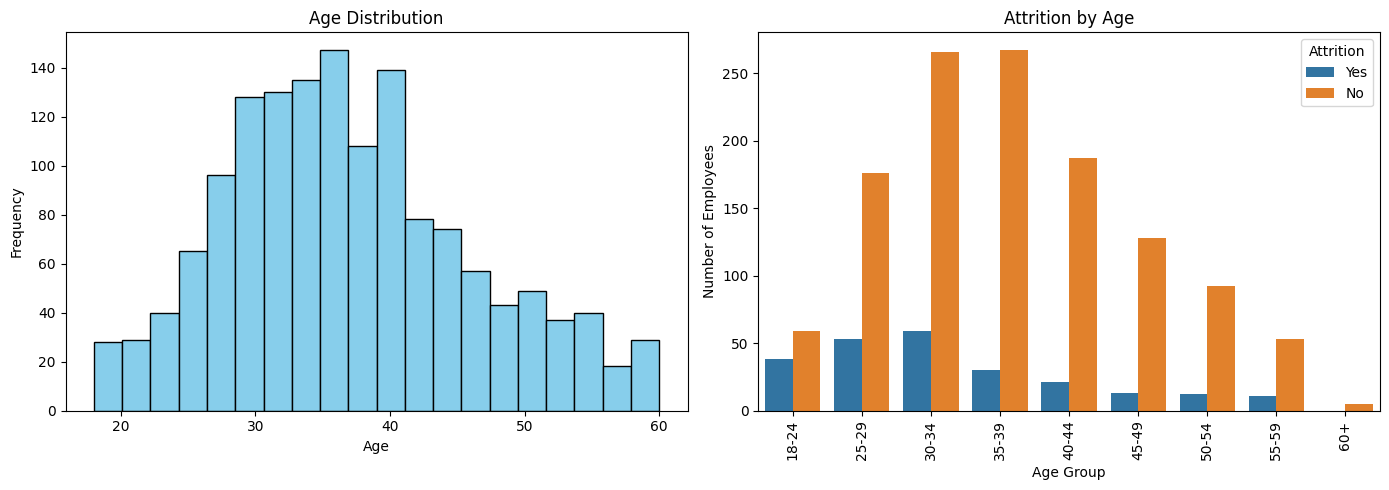

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))


ax[0].hist(df["Age"], bins=20, color="skyblue", edgecolor="black")
ax[0].set_title("Age Distribution")
ax[0].set_xlabel("Age")
ax[0].set_ylabel("Frequency")


df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[18, 24, 29, 34, 39, 44, 49, 54, 59, np.inf],
    labels=["18-24","25-29","30-34","35-39","40-44","45-49","50-54","55-59","60+"],
    include_lowest=True
)

sns.countplot(
    data=df,
    x="AgeGroup",
    hue="Attrition",
    ax=ax[1],
)

ax[1].set_title("Attrition by Age")
ax[1].set_xlabel("Age Group")
ax[1].set_ylabel("Number of Employees")
ax[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

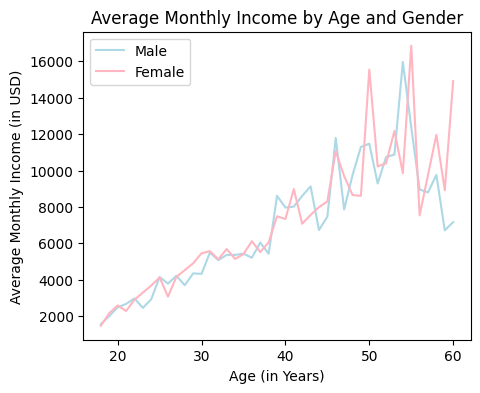

In [5]:
plt.figure(figsize=(5, 4))

male = df[df["Gender"] == "Male"]
female = df[df["Gender"] == "Female"]

plt.plot(
    male.groupby("Age")["MonthlyIncome"].mean(),
    label="Male", color='lightblue'
)
plt.plot(
    female.groupby("Age")["MonthlyIncome"].mean(),
    label="Female", color='lightpink'
)
plt.xlabel("Age (in Years)")
plt.ylabel("Average Monthly Income (in USD)")
plt.title("Average Monthly Income by Age and Gender")
plt.legend()

plt.show()

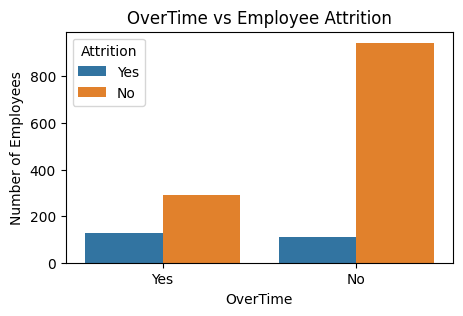

In [11]:
plt.figure(figsize=(5, 3))

sns.countplot(
    data=df,
    x="OverTime",
    hue="Attrition"
)

plt.title("OverTime vs Employee Attrition")
plt.xlabel("OverTime")
plt.ylabel("Number of Employees")
plt.show()

## Preparation of Data for Model Training :
 - Encoding
 - Splitting of Data

In [6]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split


In [7]:
for col in df.columns:
    if df[col].nunique() == 1:
        print(col)

df.drop(columns=[
    "EmployeeCount",
    "Over18",
    "StandardHours"
], inplace=True)

EmployeeCount
Over18
StandardHours


In [8]:
df["Attrition"] = df["Attrition"].map({"Yes":1,"No":0})
categorical_cols = df.select_dtypes(include=["object"]).columns
print(f"Categorical columns: {categorical_cols.tolist()}")

Categorical columns: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


In [9]:
encoder = LabelEncoder()

for col in  categorical_cols:
    df[col] = encoder.fit_transform(df[col])

In [17]:
df.head(1)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,AgeGroup
0,41,1,2,1102,2,1,2,1,1,2,...,1,0,8,0,1,6,4,0,5,40-44


In [10]:
X = df.drop(columns=["Attrition", "AgeGroup"])
Y = df["Attrition"]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=123, stratify=Y)


## Importing required Libraries for model training and metric verification :
- Models : Logistic Regression, Random Forest, Gradient Boost
- Metrics : Classification Report, Accuracy, ROC Score

In [29]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline


In [30]:
lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=10000,
        solver="lbfgs",
        random_state=123
    ))
])
lr.fit(X_train, Y_train)
lr.predict(X_test)
predictions = lr.predict(X_test)
lr_accuracy = accuracy_score(Y_test, predictions)
print(f"Logistic Regression Accuracy: {lr_accuracy:.4f}")
print(classification_report(Y_test, predictions))
lr_probs = lr.predict_proba(X_test)[:,1]
print("ROC-AUC:", roc_auc_score(Y_test, lr_probs))

Logistic Regression Accuracy: 0.8639
              precision    recall  f1-score   support

           0       0.88      0.97      0.92       247
           1       0.65      0.32      0.43        47

    accuracy                           0.86       294
   macro avg       0.77      0.64      0.68       294
weighted avg       0.85      0.86      0.84       294

ROC-AUC: 0.8060987165130501


In [31]:
rf = RandomForestClassifier(n_estimators=500,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=123)
rf.fit(X_train, Y_train)
rf_predictions = rf.predict(X_test)
accuracy = accuracy_score(Y_test, rf_predictions)
print(f"Random Forest Accuracy: {accuracy:.4f}")

Random Forest Accuracy: 0.8571


In [33]:
gb = GradientBoostingClassifier(n_estimators=1000,learning_rate=0.1,max_depth=5,random_state=123)
gb.fit(X_train, Y_train)
gb_predictions = gb.predict(X_test)
accuracy = accuracy_score(Y_test, gb_predictions)
print(f"Gradient Boosting Accuracy: {accuracy:.4f}")

Gradient Boosting Accuracy: 0.8673


In [34]:
print(classification_report(Y_test, gb_predictions))

              precision    recall  f1-score   support

           0       0.88      0.97      0.92       247
           1       0.68      0.32      0.43        47

    accuracy                           0.87       294
   macro avg       0.78      0.65      0.68       294
weighted avg       0.85      0.87      0.85       294



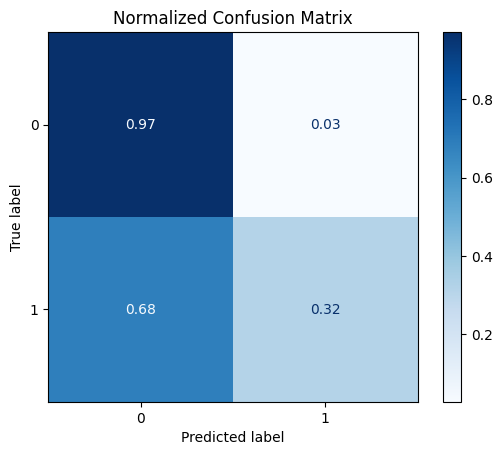

In [39]:
ConfusionMatrixDisplay.from_estimator(
    gb,
    X_test,
    Y_test,
    normalize='true',
    cmap='Blues',
    values_format='.2f'
)
plt.title("Normalized Confusion Matrix")
plt.show()

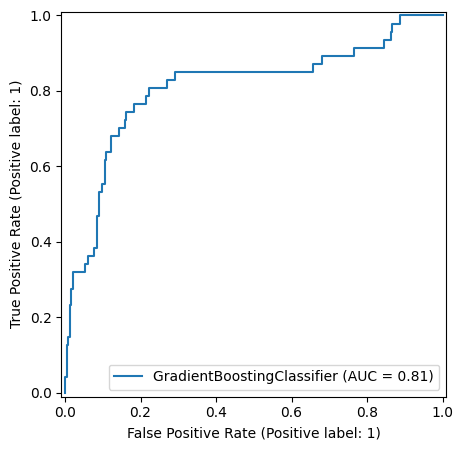

In [51]:
fig, ax = plt.subplots(figsize=(5, 5))
RocCurveDisplay.from_estimator(gb, X_test, Y_test, ax=ax)

plt.show()

Using RandomizedCV Search to find the most optimal and accurate parameters for the model.

In [12]:
from sklearn.model_selection import RandomizedSearchCV

In [14]:
parameters = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "max_depth": [2, 3, 4, 5, 6],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "subsample": [0.6, 0.8, 1.0],
    "max_features": ["sqrt", "log2", None]
}

In [55]:
gb = GradientBoostingClassifier(random_state=123)
random_search = RandomizedSearchCV(estimator=gb, param_distributions=parameters, n_iter=50, cv=5, scoring='accuracy', random_state=123, n_jobs=2)
random_search.fit(X_train, Y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...dom_state=123)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'learning_rate': [0.01, 0.03, ...], 'max_depth': [2, 3, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be us

In [56]:
print(f"Best parameters found: {random_search.best_params_}")
print(f"Best CV score from RandomizedSearchCV: {random_search.best_score_:.4f}")
print(f"Best accuracy score from RandomizedSearchCV: {random_search.best_score_:.4f}")

Best parameters found: {'subsample': 1.0, 'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 3, 'learning_rate': 0.05}
Best CV score from RandomizedSearchCV: 0.8724
Best accuracy score from RandomizedSearchCV: 0.8724


In [57]:
best_gb = random_search.best_estimator_
best_gb_predictions = best_gb.predict(X_test)
accuracy = accuracy_score(Y_test, best_gb_predictions)
print(f"Best Gradient Boosting Accuracy: {accuracy:.4f}")


Best Gradient Boosting Accuracy: 0.8741


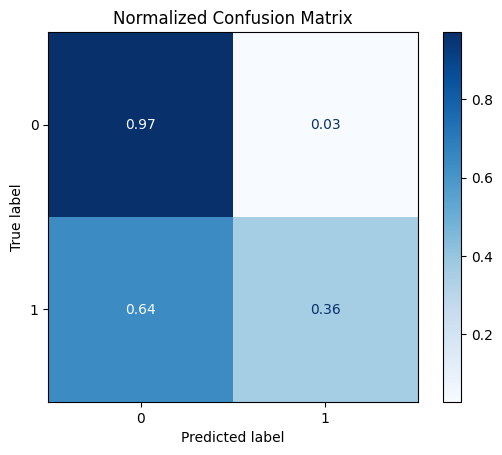

In [60]:
ConfusionMatrixDisplay.from_estimator(
    best_gb,
    X_test,
    Y_test,
    normalize='true',
    cmap='Blues',
    values_format='.2f'
)
plt.title("Normalized Confusion Matrix")
plt.show()

In [62]:
y_prob = best_gb.predict_proba(X_test)[:, 1]
print("ROC-AUC  :", roc_auc_score(Y_test, y_prob))
print(classification_report(Y_test, best_gb_predictions))

ROC-AUC  : 0.8328882763373245
              precision    recall  f1-score   support

           0       0.89      0.97      0.93       247
           1       0.71      0.36      0.48        47

    accuracy                           0.87       294
   macro avg       0.80      0.67      0.70       294
weighted avg       0.86      0.87      0.86       294



## Hyperparameter Training:
 - Model : XGBClassifier (as it had the most accuracy in previous training)
 - Bias Management : SMOTE (Synthetic Minority Oversampling Technique)

In [15]:
from imblearn.over_sampling import SMOTE

In [16]:
smote = SMOTE(random_state=123)

X_train_sm, Y_train_sm = smote.fit_resample(
    X_train,
    Y_train)

# best_gb.fit(X_train_sm, Y_train_sm)
# predictions_sm = best_gb.predict(X_test)
# accuracy_sm = accuracy_score(Y_test, predictions_sm)
# print(f"Gradient Boosting Accuracy after SMOTE: {accuracy_sm:.4f}")

In [69]:

y_pred = best_gb.predict(X_test)
y_prob = best_gb.predict_proba(X_test)[:, 1]

print(classification_report(Y_test, y_pred))
print("ROC-AUC:", roc_auc_score(Y_test, y_prob))

              precision    recall  f1-score   support

           0       0.88      0.92      0.90       247
           1       0.46      0.36      0.40        47

    accuracy                           0.83       294
   macro avg       0.67      0.64      0.65       294
weighted avg       0.82      0.83      0.82       294

ROC-AUC: 0.7903350848479629


In [17]:
from xgboost import XGBClassifier

In [18]:
param_dist = {
    "n_estimators": [100, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7],
    "min_child_weight": [1, 3, 5],
    "subsample": [0.7, 0.85, 1.0],
    "colsample_bytree": [0.7, 0.85, 1.0],
    "gamma": [0, 0.25, 0.5]
}

In [19]:
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=123,
    eval_metric="logloss"
)
xgb.fit(X_train_sm, Y_train_sm)
xgb_predictions = xgb.predict(X_test)
accuracy_xgb = accuracy_score(Y_test, xgb_predictions)
print(f"XGBoost Accuracy: {accuracy_xgb:.4f}")

XGBoost Accuracy: 0.8469


In [24]:
xgb = XGBClassifier(random_state=123,eval_metric="logloss", tree_method="hist")
random_search = RandomizedSearchCV(estimator=xgb, param_distributions=param_dist, n_iter=20, scoring="roc_auc", cv=3, verbose=2, random_state=123, n_jobs=1)
random_search.fit(X_train_sm, Y_train_sm)
best_xgb = random_search.best_estimator_
xgb_predictions = best_xgb.predict(X_test)
accuracy = accuracy_score(Y_test, xgb_predictions)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END colsample_bytree=0.85, gamma=0.5, learning_rate=0.05, max_depth=5, min_child_weight=5, n_estimators=300, subsample=1.0; total time=   0.0s
[CV] END colsample_bytree=0.85, gamma=0.5, learning_rate=0.05, max_depth=5, min_child_weight=5, n_estimators=300, subsample=1.0; total time=   0.0s
[CV] END colsample_bytree=0.85, gamma=0.5, learning_rate=0.05, max_depth=5, min_child_weight=5, n_estimators=300, subsample=1.0; total time=   0.0s
[CV] END colsample_bytree=0.85, gamma=0.25, learning_rate=0.05, max_depth=7, min_child_weight=3, n_estimators=500, subsample=0.7; total time=   0.1s
[CV] END colsample_bytree=0.85, gamma=0.25, learning_rate=0.05, max_depth=7, min_child_weight=3, n_estimators=500, subsample=0.7; total time=   0.1s
[CV] END colsample_bytree=0.85, gamma=0.25, learning_rate=0.05, max_depth=7, min_child_weight=3, n_estimators=500, subsample=0.7; total time=   0.1s
[CV] END colsample_bytree=1.0, gamma=0.25, learn

In [26]:
print(f"Best XGBoost Accuracy: {accuracy:.4f}")

print(classification_report(Y_test, xgb_predictions))

print(confusion_matrix(Y_test, xgb_predictions))

print("ROC-AUC:", roc_auc_score(Y_test, best_xgb.predict_proba(X_test)[:,1]))

Best XGBoost Accuracy: 0.8401
              precision    recall  f1-score   support

           0       0.88      0.94      0.91       247
           1       0.50      0.30      0.37        47

    accuracy                           0.84       294
   macro avg       0.69      0.62      0.64       294
weighted avg       0.82      0.84      0.82       294

[[233  14]
 [ 33  14]]
ROC-AUC: 0.7911964854853991


In [27]:
ratio = len(Y_train[Y_train==0]) / len(Y_train[Y_train==1])

print(ratio)

xgb_weighted = XGBClassifier(
    random_state=123,
    eval_metric="logloss",
    scale_pos_weight=ratio,
    tree_method="hist"
)

xgb_weighted.fit(X_train, Y_train)

pred = xgb_weighted.predict(X_test)

print(classification_report(Y_test,pred))

5.189473684210526
              precision    recall  f1-score   support

           0       0.90      0.96      0.93       247
           1       0.66      0.45      0.53        47

    accuracy                           0.87       294
   macro avg       0.78      0.70      0.73       294
weighted avg       0.86      0.87      0.86       294



In [28]:
from sklearn.metrics import classification_report

probs = xgb_weighted.predict_proba(X_test)[:,1]

for threshold in [0.25,0.3,0.35,0.4,0.45,0.5]:

    preds = (probs >= threshold).astype(int)

    print("\nThreshold:", threshold)
    print(classification_report(Y_test, preds))


Threshold: 0.25
              precision    recall  f1-score   support

           0       0.92      0.89      0.91       247
           1       0.51      0.57      0.54        47

    accuracy                           0.84       294
   macro avg       0.71      0.73      0.72       294
weighted avg       0.85      0.84      0.85       294


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.92      0.92      0.92       247
           1       0.57      0.55      0.56        47

    accuracy                           0.86       294
   macro avg       0.74      0.74      0.74       294
weighted avg       0.86      0.86      0.86       294


Threshold: 0.35
              precision    recall  f1-score   support

           0       0.91      0.93      0.92       247
           1       0.60      0.53      0.56        47

    accuracy                           0.87       294
   macro avg       0.75      0.73      0.74       294
weighted avg       0.86 